**Universidad Internacional de la Rioja**<br/>
__Filtros espaciales y morfologicos__<br/>
__Uso de Filtros espaciales y operadores morfologicos para la segmentacion y procesado de MIR Cerebrales para la identificacion de tumores cerebrales__<br/>
_Omar Francisco Velazquez Juarez, 19/07/2021_

__Instrucciones:__
<ol>
    <li>
        Ejecute el Notebook empleando el boton de Reiniciar Kernel y Re-ejecutar todo el Notebook.
    </li>
    <li>
        En el cuadro texto seleccione el numero de la imagen del set que desea procesar [1 a 5].
    </li>
    <li>
        Haga scroll hasta el final del notebook para ver los resultados.
    </li>
</ol>

__NOTA IMPORTANTE:__ El notebook tarda en ejecutarse entre 1 y 5 minutos dependiendo de la capacidad. del ordenador, _si tarda mas de este tiempo, es recomendable pensar comprar uno nuevo:)_

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


__Librerias y paquetes empleados__ <br/>
__skimage__ <br/>
Se empleo la librería skimage del paquete scikit para poder realizar la lectura de los archivos de imágenes y su transformación en arrays, documentación en:
https://scikit-image.org/docs/stable/#

__matplotlib__ <br/>
Librería de Python empleada para graficar _plottear_ gráficos en pantalla, en este proyecto fue empleada para mostrar las imagenes empleadas, asi como las distintas etapas del pre proceso, proceso y toma de desiciones.

__numpy__ <br/>
Paquete de Python para computo científico, provee librerías para el manejo multidimensional de objetos de array y otras matrices y vectores, rutinas de ordenación para la operación rápida de arrays, así como librerías matemáticas y estadísticas para la manipulación de los datos.
En este proyecto fue empleada para la ejecución de los métodos para filtros estadísticos.

__opencv 2__ <br/>
Es una biblioteca libre de visión artificial originalmente desarrollada por Intel. OpenCV significa Open Computer Vision (Visión Artificial Abierta). En esta implementacion es la version 4.0.1

In [ ]:
!pip install opencv-python

In [ ]:
import os
from skimage import io
from skimage.filters import gaussian, median
from skimage.filters import threshold_li
from skimage.transform import rotate
from skimage.color import rgb2gray, rgba2rgb
from skimage.exposure import equalize_adapthist
from skimage import morphology as mph
from skimage import util
from skimage import exposure
from skimage.measure import euler_number
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [ ]:
class DetenerEjecucion(Exception):
    def _render_traceback_(self):
        pass


__Adquisicion de Imagen__

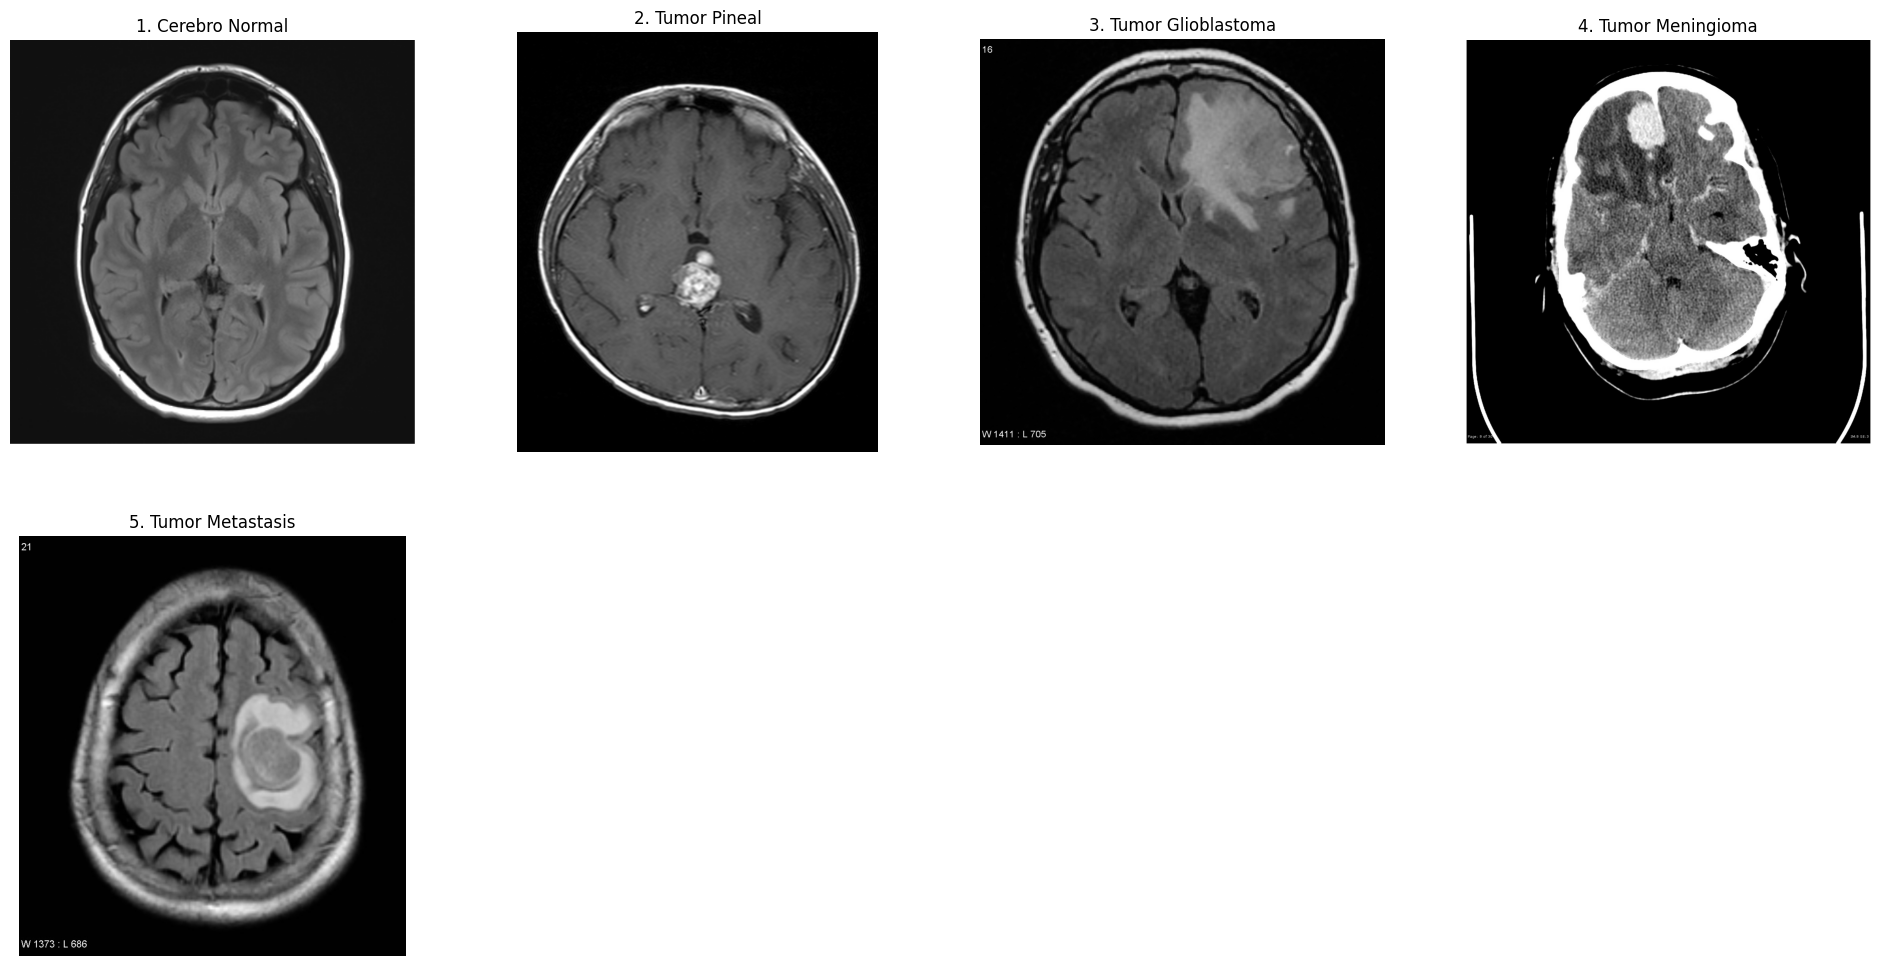

Esto tardara un momento, sugiero hacer scroll hasta el final de la pagina!!


In [ ]:
#Lectura de Imagenes
imagen_pineal = io.imread('./originales/pineal.jpg') # OK
imagen_normal = io.imread('./originales/normal-brain-mri-5.png') # OK
imagen_glioblastoma = io.imread('./originales/glioblastoma-nos-4.jpg') # regular
imagen_meningioma = io.imread('./originales/meningioma-71.jpg')
imagen_metastasis = io.imread('./originales/ring-enhancing-cerebral-metastasis.jpg')

#Seleccion de una de las imagenes MRI para procesar
fig, ax = plt.subplots(2, 4, figsize=(24, 12))
ax[0,0].imshow(imagen_normal, cmap='gray')
ax[0,0].set_title('1. Cerebro Normal')
ax[0,0].set_axis_off()
ax[0,1].imshow(imagen_pineal, cmap='gray')
ax[0,1].set_title('2. Tumor Pineal')
ax[0,1].set_axis_off()
ax[0,2].imshow(imagen_glioblastoma, cmap='gray')
ax[0,2].set_title('3. Tumor Glioblastoma')
ax[0,2].set_axis_off()
ax[0,3].imshow(imagen_meningioma, cmap='gray')
ax[0,3].set_title('4. Tumor Meningioma')
ax[0,3].set_axis_off()
ax[1,0].imshow(imagen_metastasis, cmap='gray')
ax[1,0].set_title('5. Tumor Metastasis')
ax[1,0].set_axis_off()
ax[1,1].set_title(' ')
ax[1,1].set_axis_off()
ax[1,2].set_title(' ')
ax[1,2].set_axis_off()
ax[1,3].set_title(' ')
ax[1,3].set_axis_off()
plt.show()

seleccione_imagen = 2 #input('Seleccione el MRI que desea usar:  ')
try:
    if 1 == int(seleccione_imagen):
        imagen_procesar = imagen_normal
        titulo = 'Cerebro normal'
        kernel_radio = 39
        umbral_l = 99
        umbral_h = 100
    elif 2 == int(seleccione_imagen):
        imagen_procesar = imagen_pineal
        titulo = 'Tumor pineal'
        kernel_radio = 39
        umbral_l = 0
        umbral_h = 15
    elif 3 == int(seleccione_imagen):
        imagen_procesar = imagen_glioblastoma
        titulo = 'Tumor glioblastoma'
        kernel_radio = 39
        umbral_l = 0
        umbral_h = 10
    elif 4 == int(seleccione_imagen):
        imagen_procesar = imagen_meningioma
        titulo = 'Tumor meningioma'
        kernel_radio = 17
        umbral_l = 0
        umbral_h = 15
    elif 5 == int(seleccione_imagen):
        imagen_procesar = imagen_metastasis
        titulo = 'Tumor metastasis'
        kernel_radio = 39
        umbral_l = 0
        umbral_h = 10
    else:
        print('Dato fuera de rango, introdusca un valor entre 1 y 5')
        raise DetenerEjecucion()
except:
    print('Debe introducir un numero entre 1 y 5')
    raise DetenerEjecucion()

print('Esto tardara un momento, sugiero hacer scroll hasta el final de la pagina!!')

__Pre-procesado de imagen__

In [ ]:
# Conversion a escala de grises
try:
    imagen_grises = rgb2gray(rgba2rgb(imagen_procesar))
except:
    imagen_grises = rgb2gray(imagen_procesar)

# Aplicamos filtro ecualizacion adaptiativa para resaltar imagen
imagen_clahe = equalize_adapthist(imagen_grises)
# Aplicamos transformacion logaritmica para expandir rango intensidad
imagen_logaritmica = exposure.adjust_log(imagen_clahe,1)
# Aplicamos transformacion de la imagen a negativa
imagen_negativa = util.invert(imagen_logaritmica)


__Procesamiento de la imagen__

In [ ]:
imagen_preprocesada = imagen_negativa
kernel = mph.disk(kernel_radio)

# Aplicamos Operacion de clausura para aislar objetos
paso_1 =  mph.closing(imagen_preprocesada, kernel)

# Binarizar imagen
thresh = threshold_li(paso_1)
paso_2 = paso_1 > thresh

# Invertir imagen para crear mascara
paso_3 = util.invert(paso_2)
# Multiplicar la mascara con la imagen engrises
paso_4 = cv2.multiply(imagen_preprocesada ,paso_3.astype(float))
#Pasamos fondo a blanco
imagen_resultado = np.where(paso_4 == 0, 1, paso_4)

# Rescalamos la intensiadad para ajustarse a los umbrales del tumor y resaltarlo
pL, pH = np.percentile(imagen_resultado, (umbral_l, umbral_h))
resaltamos_imagenes = exposure.rescale_intensity(imagen_resultado, in_range=(pL,pH))

#Binarizamos el tumor detectado para crar nueva mascara
thresh = threshold_li(resaltamos_imagenes)
tumor_detectado = resaltamos_imagenes > thresh

#Con la mascara del tumor detectado, mostramos tumor
mascara_tumor = util.invert(tumor_detectado)
tumor_filtrado = cv2.multiply(imagen_grises ,mascara_tumor.astype(float))
#pasamos fondo a blanco
tumor_filtrado = np.where(tumor_filtrado == 0, 1, tumor_filtrado)

__Toma desicion y presentacion de resultados__

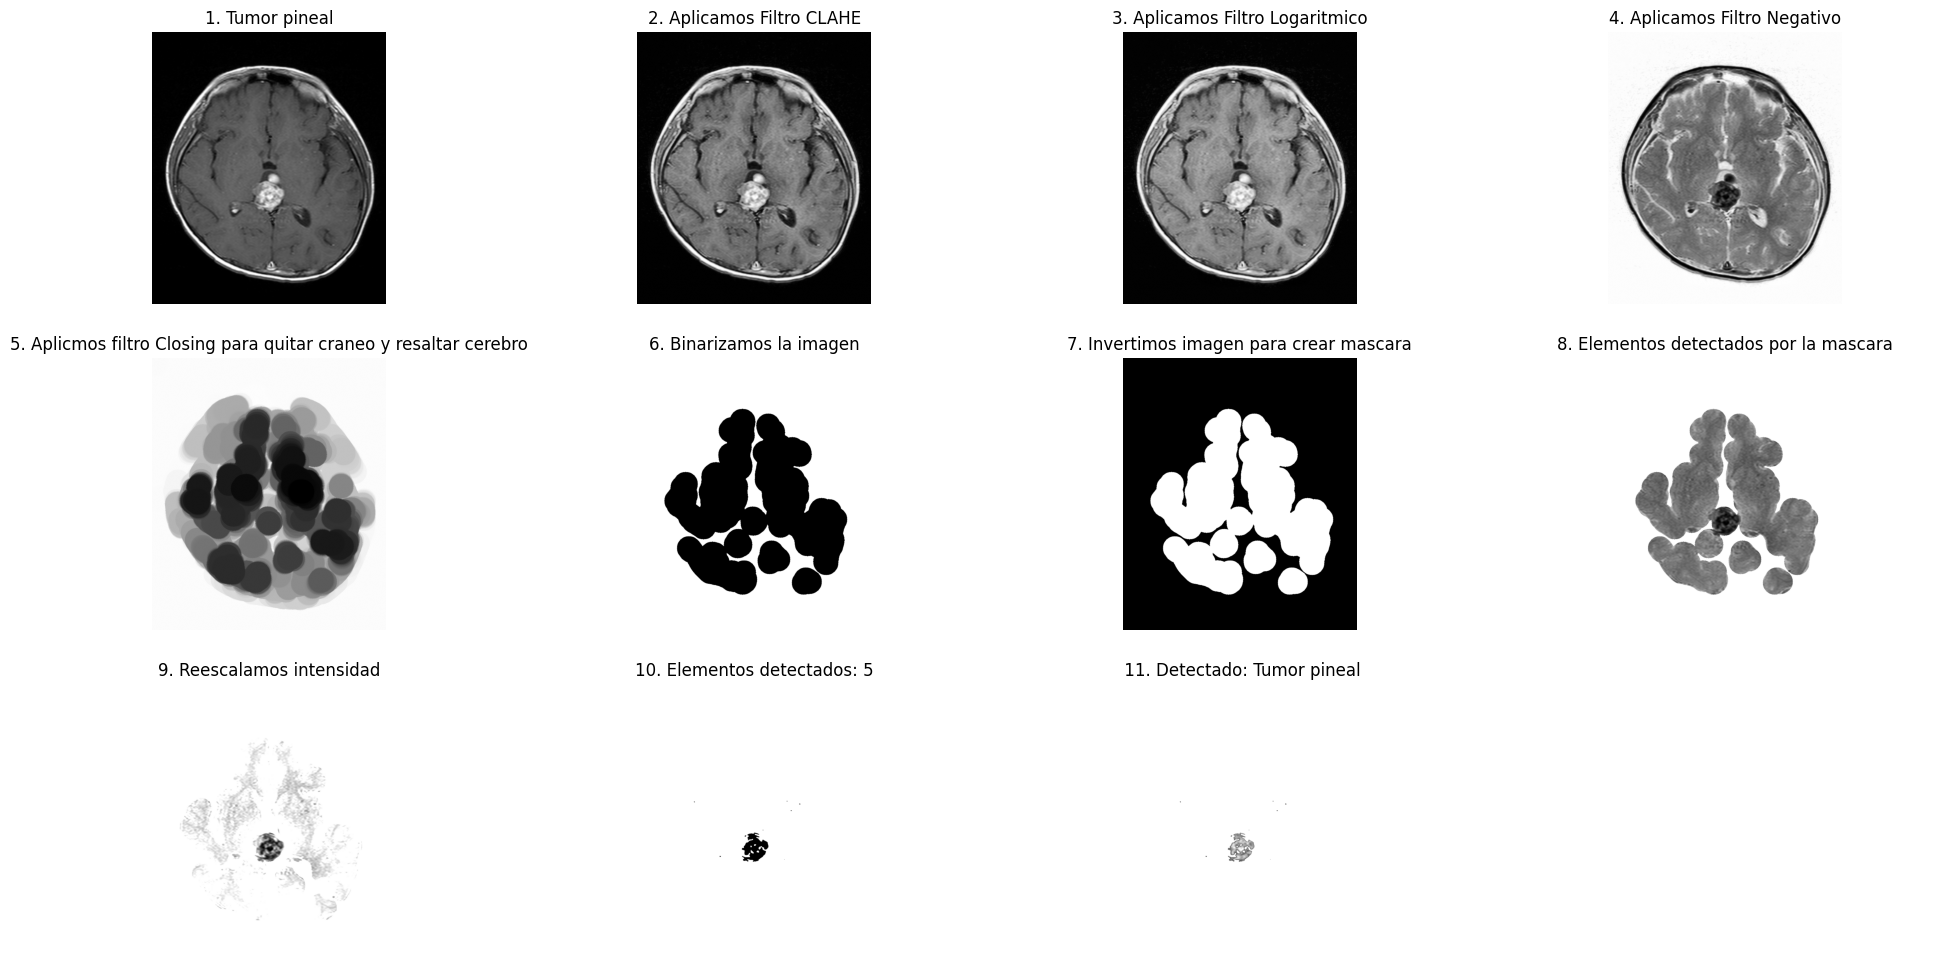

In [ ]:
# Contar el numero de elementos con euler
euler = euler_number(util.invert(tumor_detectado), connectivity=None)

# Presentacion de los resultados
# Pre proceso
fig, ax = plt.subplots(3, 4, figsize=(24, 12))
ax[0,0].imshow(imagen_procesar, cmap='gray')
ax[0,0].set_title('1. ' + titulo)
ax[0,0].set_axis_off()
ax[0,1].imshow(imagen_clahe, cmap='gray')
ax[0,1].set_title('2. Aplicamos Filtro CLAHE')
ax[0,1].set_axis_off()
ax[0,2].imshow(imagen_logaritmica, cmap='gray')
ax[0,2].set_title('3. Aplicamos Filtro Logaritmico')
ax[0,2].set_axis_off()
ax[0,3].imshow(imagen_negativa, cmap='gray')
ax[0,3].set_title('4. Aplicamos Filtro Negativo')
ax[0,3].set_axis_off()
# Proceso
ax[1,0].imshow(paso_1, cmap='gray')
ax[1,0].set_title('5. Aplicmos filtro Closing para quitar craneo y resaltar cerebro')
ax[1,0].set_axis_off()
ax[1,1].imshow(paso_2, cmap='gray')
ax[1,1].set_title('6. Binarizamos la imagen')
ax[1,1].set_axis_off()
ax[1,2].imshow(paso_3, cmap='gray')
ax[1,2].set_title('7. Invertimos imagen para crear mascara')
ax[1,2].set_axis_off()
ax[1,3].imshow(imagen_resultado, cmap='gray')
ax[1,3].set_title('8. Elementos detectados por la mascara')
ax[1,3].set_axis_off()
# Toma de desicion
ax[2,0].imshow(resaltamos_imagenes, cmap='gray')
ax[2,0].set_title('9. Reescalamos intensidad')
ax[2,0].set_axis_off()
ax[2,1].imshow(tumor_detectado, cmap='gray')
ax[2,1].set_title('10. Elementos detectados: ' + str(abs(euler)))
ax[2,1].set_axis_off()
ax[2,2].imshow(tumor_filtrado, cmap='gray')
ax[2,2].set_title(' 11. Detectado: ' + titulo)
ax[2,2].set_axis_off()
ax[2,3].set_title(' ')
ax[2,3].set_axis_off()
plt.show()


__Bibliografia y referencias__ <br/>
_Bibliografia_
<ul>
    <li>
        Rohini P., Senthil S., Manikandan M. (2014). Brain Tumor Mri Image Segmentation And Detection In Image Processing, International Journal of Research in Engineering and Technology eISSN: 2319-1163 | pISSN: 2321-7308, recuperado 17/07/2021.
    </li>
    <li>
        Isselmou, A. , Zhang, S. and Xu, G. (2016) A Novel Approach for Brain Tumor Detection Using MRI Images. Journal of Biomedical Science and Engineering, 9, 44-52. doi: 10.4236/jbise.2016.910B006.
    </li>
    <li>
        Dogdas B., Shattuck D., Leahy R. (2005). Segmentation of Skull and Scalp in 3-D Human MRI Using Mathematical Morphology, Human Brain Mapping 26:273–285, recuperado 17/07/2021.
    </li>
</ul>

_Imagenes_<br/>
Fuente: https://radiopaedia.org
<ul>
    <li>
       MRI Axial FLAIR de Cerebro Normal, Caso cortesía de la Asociación Prof. Frank Gaillard, Radiopaedia.org, rID: 5563.
   </li>   
   <li>
       MRI Axial T1 C+ de Tumor de células germinativas no germinomatoso (pineal), caso cortesía de la Asociación Prof. Frank Gaillard, Radiopaedia.org, rID: 5687.
   </li>
   <li>
       MRI Axial T1 C+ de Glioblastoma multiforme, caso cortesía de la Asociación Prof. Frank Gaillard, Radiopaedia.org, rID: 5292.
   </li>
   <li>
      MRI C delayed de Meningioma, caso cortesía de la Asociación Prof. Frank Gaillard, Radiopaedia.org, rID: 14109.
   </li>
   <li>
      MRI Axial T1 C+ Metástasis cerebral de anillo realzado, caso cortesía de la Asociación Prof. Frank Gaillard, Radiopaedia.org, rID: 5563.
   </li>
</ul>

####